In [19]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import shap

In [2]:
# Define Columns I Want
selected_features = ['age_s1', 'gender', 'bmi_s1', 'race', 'mnsao2rh', 'avhrbp', 'neck20', 'ess_s1', 'systbp', 'smokstat_s1', 'rdi3p']

# Load Dataset
df = pd.read_csv('shhs1-dataset-0.21.0.csv', usecols = selected_features)

print(df.shape)
df.head()

(5804, 11)


,rdi3p,mnsao2rh,avhrbp,gender,race,systbp,neck20,age_s1,smokstat_s1,ess_s1,bmi_s1
0,4.154461,85.0,NaN,1,1,143.0,38.3,55,2.0,6.0,21.777553
1,30.989011,87.0,NaN,1,1,168.0,40.5,78,0.0,14.0,32.950680
2,8.870293,82.0,NaN,2,1,127.0,39.0,77,0.0,5.0,24.114150
3,2.591362,92.0,22.127659,1,1,130.0,39.2,48,0.0,11.0,20.185185
4,6.162162,83.0,NaN,2,2,145.0,32.0,66,2.0,7.0,23.309053


In [3]:
# Deal with Missing Values
print('Count of Missing Values by Variable Before Imputation:')
print(df.isnull().sum())

# Median Imputation for Continuous Variables
continuous_cols = ['bmi_s1', 'mnsao2rh', 'avhrbp', 'neck20', 'systbp', 'ess_s1']
median_imputer = SimpleImputer(strategy = 'median')
df[continuous_cols] = median_imputer.fit_transform(df[continuous_cols])

# Mode Imputation for Categorical Variables
categorical_cols = ['smokstat_s1', 'race', 'gender']
mode_imputer = SimpleImputer(strategy = 'most_frequent')
df[categorical_cols] = mode_imputer.fit_transform(df[categorical_cols])

print('Count of Missing Values by Variable After Imputation:')
print(df.isnull().sum())

Count of Missing Values by Variable Before Imputation:
rdi3p             0
mnsao2rh        166
avhrbp         2692
gender            0
race              0
systbp          113
neck20           29
age_s1            0
smokstat_s1      41
ess_s1          221
bmi_s1           43
dtype: int64
Count of Missing Values by Variable After Imputation:
rdi3p          0
mnsao2rh       0
avhrbp         0
gender         0
race           0
systbp         0
neck20         0
age_s1         0
smokstat_s1    0
ess_s1         0
bmi_s1         0
dtype: int64


In [4]:
# Categorical Encoding

# 1. Convert categorical columns to string type
df['gender'] = df['gender'].astype(str)
df['race'] = df['race'].astype(str)
df['smokstat_s1'] = df['smokstat_s1'].astype(str)

# 2. Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns = ['gender', 'race', 'smokstat_s1'], drop_first = True)

print("Columns after encoding:", df_encoded.columns.tolist())
display(df_encoded.head())

Columns after encoding: ['rdi3p', 'mnsao2rh', 'avhrbp', 'systbp', 'neck20', 'age_s1', 'ess_s1', 'bmi_s1', 'gender_2.0', 'race_2.0', 'race_3.0', 'smokstat_s1_1.0', 'smokstat_s1_2.0']


,rdi3p,mnsao2rh,avhrbp,systbp,neck20,age_s1,ess_s1,bmi_s1,gender_2.0,race_2.0,race_3.0,smokstat_s1_1.0,smokstat_s1_2.0
0,4.154461,85.0,21.125000,143.0,38.3,55,6.0,21.777553,False,False,False,False,True
1,30.989011,87.0,21.125000,168.0,40.5,78,14.0,32.950680,False,False,False,False,False
2,8.870293,82.0,21.125000,127.0,39.0,77,5.0,24.114150,True,False,False,False,False
3,2.591362,92.0,22.127659,130.0,39.2,48,11.0,20.185185,False,False,False,False,False
4,6.162162,83.0,21.125000,145.0,32.0,66,7.0,23.309053,True,True,False,False,True


In [5]:
# Target Categorization/Binning
def categorize_ahi(rdi):
    if rdi < 5:
        return 0 # None
    elif rdi < 15:
        return 1 # Mild
    elif rdi < 30:
        return 2 # Moderate
    else:
        return 3 # Severe

df_encoded['severity_class'] = df_encoded['rdi3p'].apply(categorize_ahi)

# Check the balance of your classes
print("Patient counts per severity level:")
print(df_encoded['severity_class'].value_counts().sort_index())

Patient counts per severity level:
severity_class
0    1919
1    2041
2    1163
3     681
Name: count, dtype: int64


In [6]:
# Feature Scaling
scale_cols = ['age_s1', 'bmi_s1', 'mnsao2rh', 'avhrbp', 'neck20', 'ess_s1', 'systbp']

scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

print("Preprocessing Complete. Data is now scaled and encoded.")

Preprocessing Complete. Data is now scaled and encoded.


Text(0.5, 1.0, 'Correlation Heatmap: Clinical Features vs. Apnea Severity')

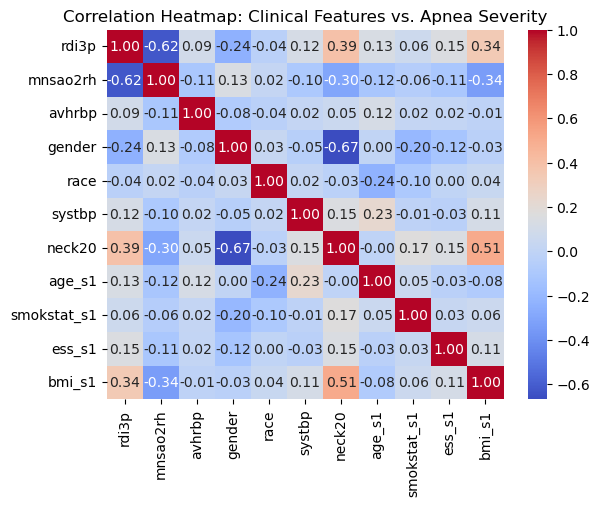

In [7]:
# Correlation Matrix

# Calculate Correlations
corr_matrix = df.corr()

# Plot Heatmap
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap: Clinical Features vs. Apnea Severity')

Text(0, 0.5, 'Number of Patients')

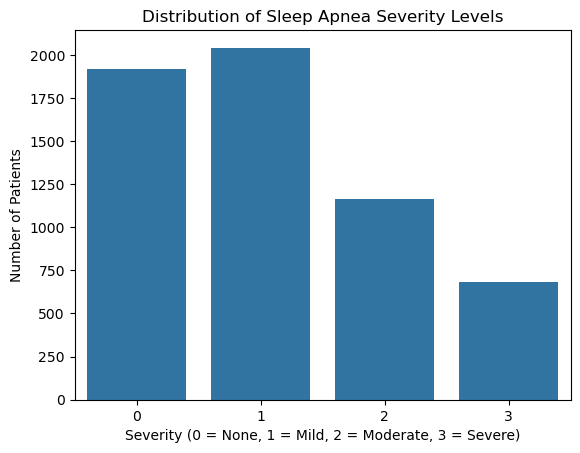

In [8]:
# Distribution of Severity
sns.countplot(x = 'severity_class', data = df_encoded)
plt.title('Distribution of Sleep Apnea Severity Levels')
plt.xlabel('Severity (0 = None, 1 = Mild, 2 = Moderate, 3 = Severe)')
plt.ylabel('Number of Patients')

Text(0.5, 1.0, 'BMI Distribution Across Apnea Severity Levels')

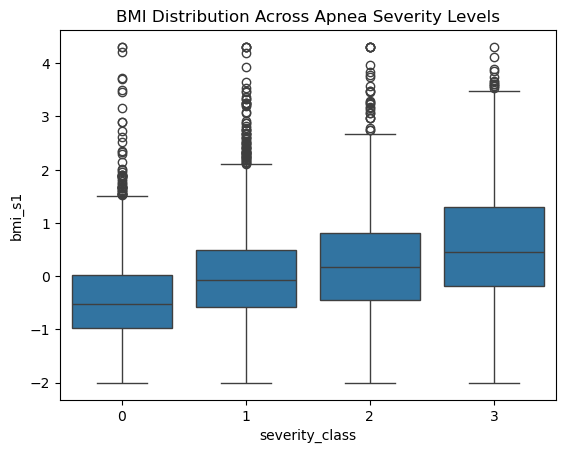

In [9]:
# Boxplot for Clinical Evidence
sns.boxplot(x = 'severity_class', y = 'bmi_s1', data = df_encoded)
plt.title('BMI Distribution Across Apnea Severity Levels')

In [11]:
# Multi-Collinearity Check (VIF)

# Check VIF on continuous numeric features
def calculate_vif(df, features):
    vif_data = pd.DataFrame()
    vif_data['feature'] = features
    vif_data['VIF'] = [variance_inflation_factor(df[features].values, i) for i in range(len(features))]
    
    return vif_data

# Define features to check
vif_features = ['age_s1', 'bmi_s1', 'mnsao2rh', 'avhrbp', 'neck20', 'systbp', 'ess_s1']

print('VIF Scores:')
print(calculate_vif(df_encoded, vif_features))

VIF Scores:
    feature       VIF
0    age_s1  1.101271
1    bmi_s1  1.454887
2  mnsao2rh  1.205279
3    avhrbp  1.028620
4    neck20  1.414203
5    systbp  1.086847
6    ess_s1  1.031654


All VIF scores are below 1.5, which means we do not need to drop any variables and that multicollinearity is not a threat to the model's stability.

In [12]:
# Feature Engineering (Interaction Term Between BMI and Age)
df_encoded['bmi_age_interaction'] = df_encoded['bmi_s1'] * df_encoded['age_s1']

# Scale new feature
df_encoded['bmi_age_interaction'] = scaler.fit_transform(df_encoded[['bmi_age_interaction']])

print('Added feature: bmi_age_interaction')

Added feature: bmi_age_interaction


In [14]:
# Data Splitting (70/15/15)

# Define Features (X) and Target (y)
# Drop raw rdi3p and new severity_class from X
X = df_encoded.drop(columns = ['rdi3p', 'severity_class'], axis = 1)
y = df_encoded['severity_class']

# First Split: 70% Training, 30% Temporary (for Val/Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.30, random_state = 42, stratify = y)

# Second Split: Split 30% into 2 Equal Halves (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.50, random_state = 42, stratify = y_temp)

print(f'Training Set: {len(X_train)}')
print(f'Validation Set: {len(X_val)}')
print(f'Test Set: {len(X_test)}')

Training Set: 4062
Validation Set: 871
Test Set: 871


In [21]:
# Baseline Logistic Regression

# Initialize Baseline Model
log_reg = LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42)

# Fit the model
log_reg.fit(X_train, y_train)

# Predict on validation set
y_val_pred = log_reg.predict(X_val)

# Evaluate
print('Baseline Logistic Regression Results (Validation Set)')
print(f'Accuracy: {accuracy_score(y_val, y_val_pred):}')
print(classification_report(y_val, y_val_pred))

Baseline Logistic Regression Results (Validation Set)
Accuracy: 0.5258323765786452
              precision    recall  f1-score   support

           0       0.67      0.71      0.69       288
           1       0.50      0.41      0.45       306
           2       0.39      0.35      0.37       175
           3       0.43      0.66      0.52       102

    accuracy                           0.53       871
   macro avg       0.50      0.53      0.51       871
weighted avg       0.52      0.53      0.52       871



In [22]:
# Random Forest (Captures Non-Linearities Like BMI Shifts Across Age)
rf_model = RandomForestClassifier(n_estimators = 100, class_weight = 'balanced', random_state = 42)
rf_model.fit(X_train, y_train)

# XGBoost (Gradient Boosting to Minimize Residuals)
xgb_model = XGBClassifier(eval_metric = 'mlogloss', random_state = 42)
xgb_model.fit(X_train, y_train)

# SVM (Hyperplane Separation in High-Dimensional Space)
svm_model = SVC(probability = True, class_weight = 'balanced', random_state = 42)
svm_model.fit(X_train, y_train)

# Validation Check
models = {'Random Forest': rf_model, 'XGBoost': xgb_model, 'SVM': svm_model}
for name, model in models.items():
    preds = model.predict(X_val)
    print(f'{name} Validation Accuracy: {accuracy_score(y_val, preds):}')

Random Forest Validation Accuracy: 0.49942594718714123
XGBoost Validation Accuracy: 0.505166475315729
SVM Validation Accuracy: 0.5109070034443168


([<matplotlib.axis.YTick at 0x2857c2aa710>,
 [Text(0, 0, 'race_3.0'),
  Text(0, 1, 'race_2.0'),
  Text(0, 2, 'smokstat_s1_1.0'),
  Text(0, 3, 'gender_2.0'),
  Text(0, 4, 'smokstat_s1_2.0'),
  Text(0, 5, 'avhrbp'),
  Text(0, 6, 'ess_s1'),
  Text(0, 7, 'age_s1'),
  Text(0, 8, 'systbp'),
  Text(0, 9, 'bmi_age_interaction'),
  Text(0, 10, 'neck20'),
  Text(0, 11, 'bmi_s1'),
  Text(0, 12, 'mnsao2rh')])

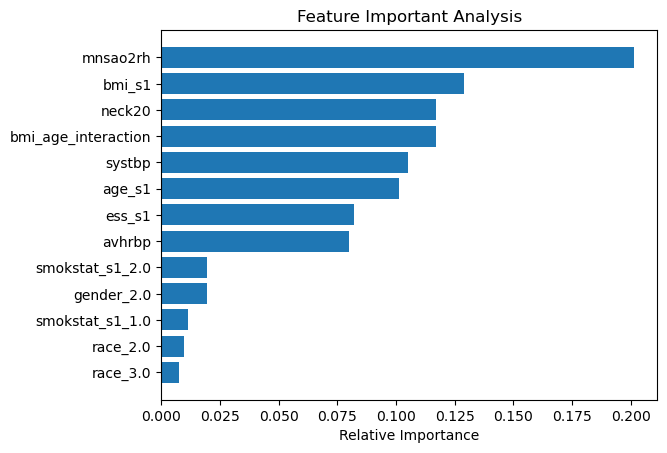

In [23]:
# Visualize Which Features Actually Matter to the Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns
indices = np.argsort(importances)

plt.barh(range(len(indices)), importances[indices], align = 'center')
plt.title('Feature Important Analysis')
plt.xlabel('Relative Importance')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

Text(0.5, 1.0, 'XGBoost Confusion Matrix: Where are the errors?')

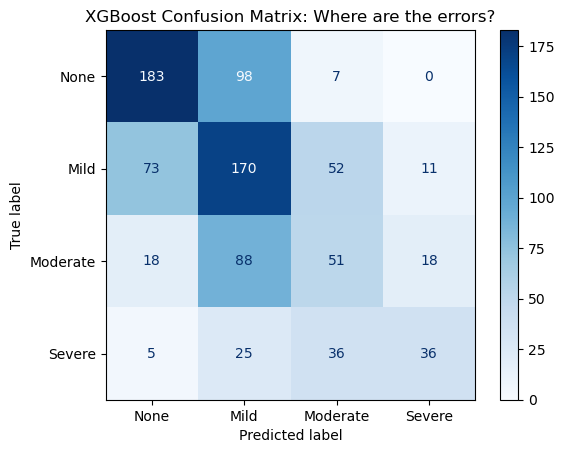

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_val, xgb_model.predict(X_val))

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['None', 'Mild', 'Moderate', 'Severe'])
disp.plot(cmap = 'Blues')
plt.title('XGBoost Confusion Matrix: Where are the errors?')

In [26]:
# Hyperparameter Tuning

# Define Grid of Settings to Try for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(estimator = xgb_model, param_grid = param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')
print(f'New Tuned Accuracy: {accuracy_score(y_val, best_xgb.predict(X_val)):}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
New Tuned Accuracy: 0.5315729047072331


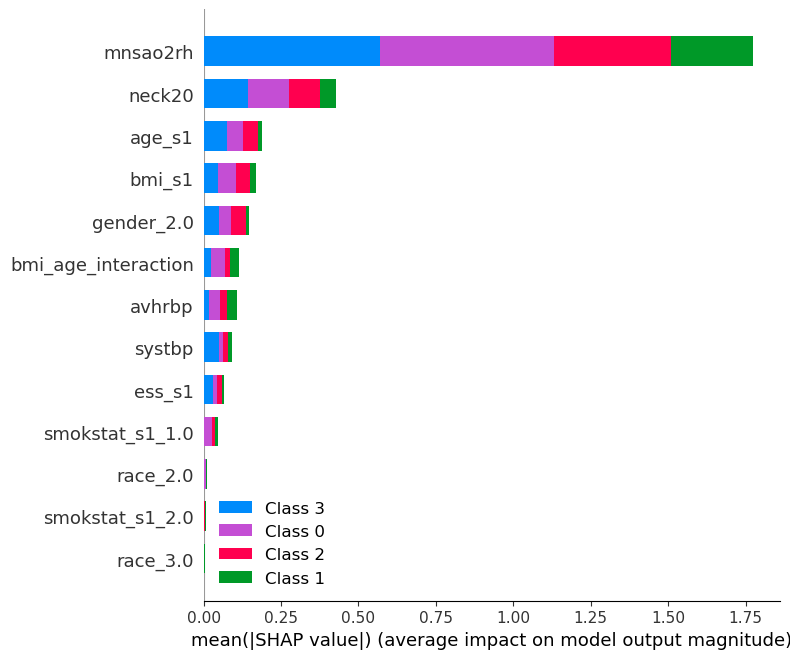

In [27]:
# SHAP Explainability ("Clinician's View")

# Initialize SHAP Explainer with Best Model
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_val)

# Summary Plot: Shows Which Features are the Most Important Globally
shap.summary_plot(shap_values, X_val, plot_type = 'bar')

Final Project Performance (Test Set)
              precision    recall  f1-score   support

           0       0.70      0.70      0.70       288
           1       0.47      0.68      0.56       307
           2       0.42      0.18      0.25       174
           3       0.54      0.34      0.42       102

    accuracy                           0.55       871
   macro avg       0.53      0.47      0.48       871
weighted avg       0.54      0.55      0.53       871



Text(0.5, 1.0, 'Final Model Performance: Test Set')

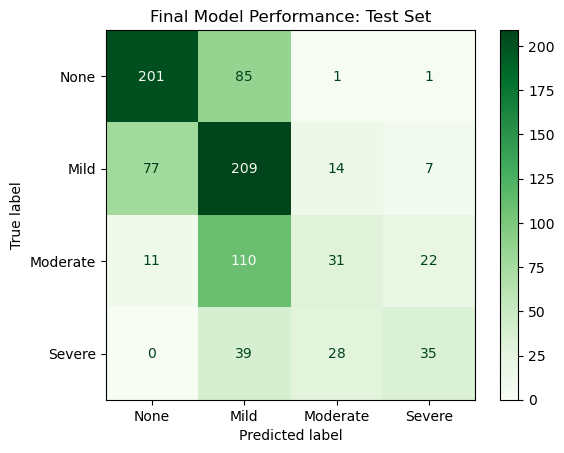

In [28]:
# Final Evaluation

# Final Test on Held-Out Test Set
final_preds = best_xgb.predict(X_test)

print('Final Project Performance (Test Set)')
print(classification_report(y_test, final_preds))

# Plot Final Confusion Matrix for Test Set
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_preds,
    display_labels = ['None', 'Mild', 'Moderate', 'Severe'],
    cmap = 'Greens'
)
plt.title('Final Model Performance: Test Set')